# Predictive Analytics: Machine Learning

**Author:** Grace Tulsi  
**Repository:** https://github.com/gracetulsi/datafun-07-ml

This notebook explores introductory machine learning concepts including simple linear regression and predictive analytics using Python, Jupyter notebooks, pandas, SciPy, seaborn, and scikit-learn. We follow guided projects aligned with textbook sections 10.16 and 15.4.

In [179]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [180]:
pd.set_option("display.precision", 2)
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports and settings complete.")

Imports and settings complete.


## Part 1 - Chart a Straight Line

We build a simple DataFrame and chart a straight-line relationship.

In [181]:
def fahrenheit_to_celsius(f: float) -> float:
    """Convert Fahrenheit to Celsius."""
    return (5 / 9) * (f - 32)

In [182]:
temps = [(f, fahrenheit_to_celsius(f)) for f in range(0, 101, 10)]
temps_df = pd.DataFrame(temps, columns=["Fahrenheit", "Celsius"])
temps_df.head()

,Fahrenheit,Celsius
0,0,-17.78
1,10,-12.22
2,20,-6.67
3,30,-1.11
4,40,4.44


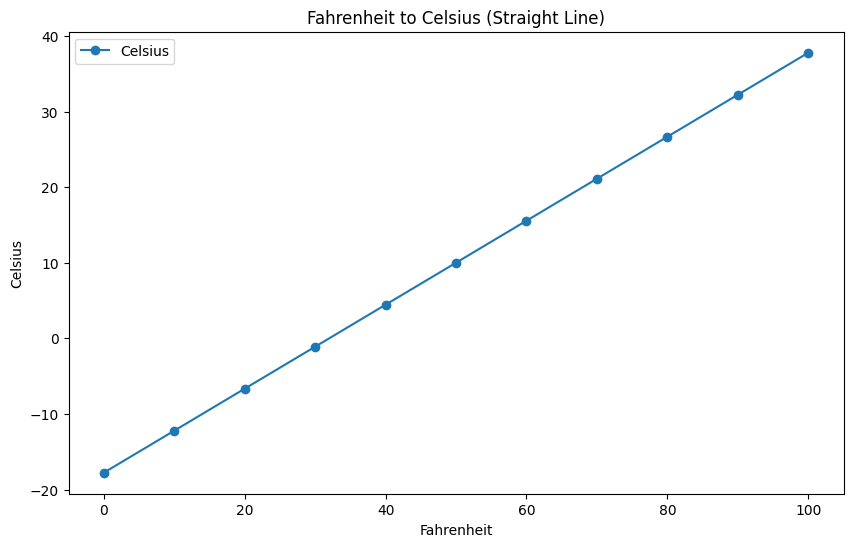

In [183]:
ax = temps_df.plot(x="Fahrenheit", y="Celsius", style="o-")
ax.set_xlabel("Fahrenheit")
ax.set_ylabel("Celsius")
ax.set_title("Fahrenheit to Celsius (Straight Line)")
plt.show()

## Part 2 - Prediction

We use NYC January average high temperature data and build a simple linear regression model using SciPy's `linregress`.

### Section 1 - Data Acquisition

Load NYC January high temperature data from a CSV into a pandas DataFrame.

In [184]:
# Section 1 - Data Acquisition


def find_project_root(start: Path) -> Path:
    """Find the repository root by searching upward for pyproject.toml or .git."""
    for folder in (start, *start.parents):
        if (folder / "pyproject.toml").exists() or (folder / ".git").exists():
            return folder
    raise FileNotFoundError(
        "Project root not found (missing pyproject.toml/.git in parent folders)."
    )


project_root = find_project_root(Path.cwd())
csv_path = project_root / "data" / "raw" / "ave_hi_nyc_jan_1895-2018.csv"

nyc_df = pd.read_csv(csv_path)
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


### Section 2 - Data Inspection

In [185]:
nyc_df.head()
nyc_df.tail()
nyc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     124 non-null    int64  
 1   Value    124 non-null    float64
 2   Anomaly  124 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.0 KB


### Section 3 - Data Cleaning

In [186]:
nyc_df = nyc_df.rename(
    columns={"Date": "Date", "Value": "Temperature", "Anomaly": "Anomaly"}
)
nyc_df["Date"] = nyc_df["Date"].floordiv(100)

nyc_clean = (
    nyc_df[["Date", "Temperature"]]
    .dropna()
    .rename(columns={"Date": "year", "Temperature": "avg_high"})
    .sort_values("year")
    .reset_index(drop=True)
)

### Section 4 - Descriptive Statistics

In [187]:
nyc_clean.describe()

,year,avg_high
count,124.00,124.00
mean,1956.50,37.60
std,35.94,4.54
min,1895.00,26.10
25%,1925.75,34.58
50%,1956.50,37.60
75%,1987.25,40.60
max,2018.00,47.60


### Section 5 - Build the Model (SciPy)

In [188]:
x = nyc_clean["year"]
y = nyc_clean["avg_high"]

result = linregress(x, y)
slope = result.slope
intercept = result.intercept

print(f"slope: {slope:.6f}")
print(f"intercept: {intercept:.6f}")
print(f"r-value: {result.rvalue:.6f}")

slope: 0.014771
intercept: 8.694993
r-value: 0.116938


### Section 6 - Predict

In [189]:
year_to_predict = 2024
pred_2024_scipy = slope * year_to_predict + intercept
print(f"Predicted NYC January avg high for {year_to_predict}: {pred_2024_scipy:.2f}°F")

Predicted NYC January avg high for 2024: 38.59°F


### Section 7 - Visualization

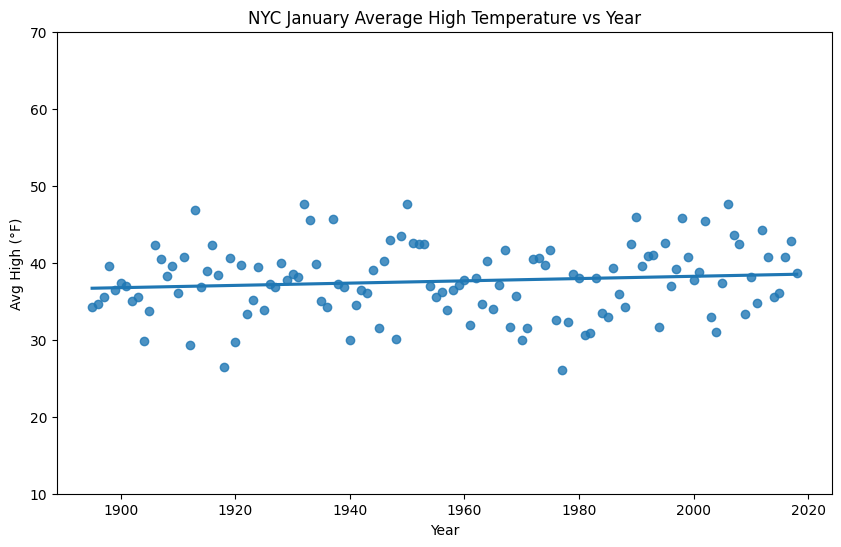

In [190]:
axes = sns.regplot(x="year", y="avg_high", data=nyc_clean, ci=None)
axes.set_ylim(10, 70)
plt.title("NYC January Average High Temperature vs Year")
plt.xlabel("Year")
plt.ylabel("Avg High (°F)")
plt.show()

## Part 3 - Prediction

We use scikit-learn to build and evaluate a linear regression model using a train/test split, then predict the NYC January average high temperature for 2024.

### Section 1 - Build the Model (scikit-learn)

In [191]:
X = nyc_clean[["year"]]  # DataFrame keeps feature name
y = nyc_clean["avg_high"]  # Series target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"coef (slope): {model.coef_[0]:.6f}")
print(f"intercept: {model.intercept_:.6f}")

coef (slope): 0.014711
intercept: 8.891971


### Section 2 - Test the Model

In [192]:
# Section 2 - Test the Model

test_pred = model.predict(X_test)

results_df = pd.DataFrame(
    {
        "year": X_test["year"].to_numpy(),
        "actual": y_test.to_numpy(),
        "predicted": test_pred,
    }
).sort_values("year")

display(results_df.head(10))

for p, e in zip(test_pred[::5], y_test.to_numpy()[::5], strict=False):
    print(f"predicted: {p:.2f}, expected: {e:.2f}")

,year,actual,predicted
6,1895,34.2,36.77
1,1897,35.5,36.80
14,1901,37.0,36.86
3,1904,29.8,36.90
24,1910,36.1,36.99
4,1911,40.7,37.00
10,1924,39.4,37.20
21,1925,33.8,37.21
22,1930,38.5,37.28
7,1931,38.2,37.30


predicted: 37.84, expected: 31.70
predicted: 38.47, expected: 34.80
predicted: 37.20, expected: 39.40
predicted: 37.39, expected: 45.70
predicted: 37.99, expected: 32.30


In [193]:
print(f"R^2 score on test set: {model.score(X_test, y_test):.4f}")

R^2 score on test set: 0.0033


### Section 3 - Predict

In [194]:
pred_2024_sklearn = model.predict(pd.DataFrame({"year": [2024]}))[0]
print(
    f"Predicted NYC January avg high for 2024 (scikit-learn): {pred_2024_sklearn:.2f}°F"
)

Predicted NYC January avg high for 2024 (scikit-learn): 38.67°F


### Section 4 - Visualization

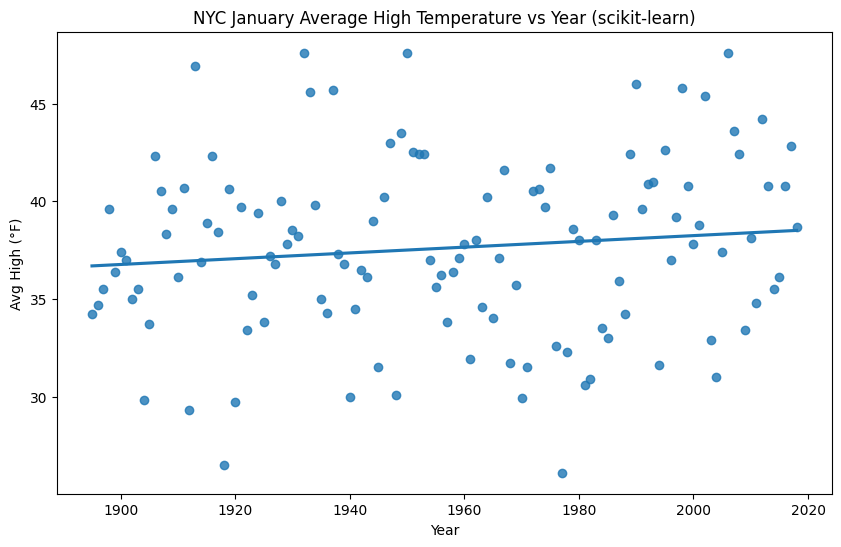

In [195]:
sns.regplot(x="year", y="avg_high", data=nyc_clean, ci=None)
plt.title("NYC January Average High Temperature vs Year (scikit-learn)")
plt.xlabel("Year")
plt.ylabel("Avg High (°F)")
plt.show()

### Section 5 - Project Highlight Chart

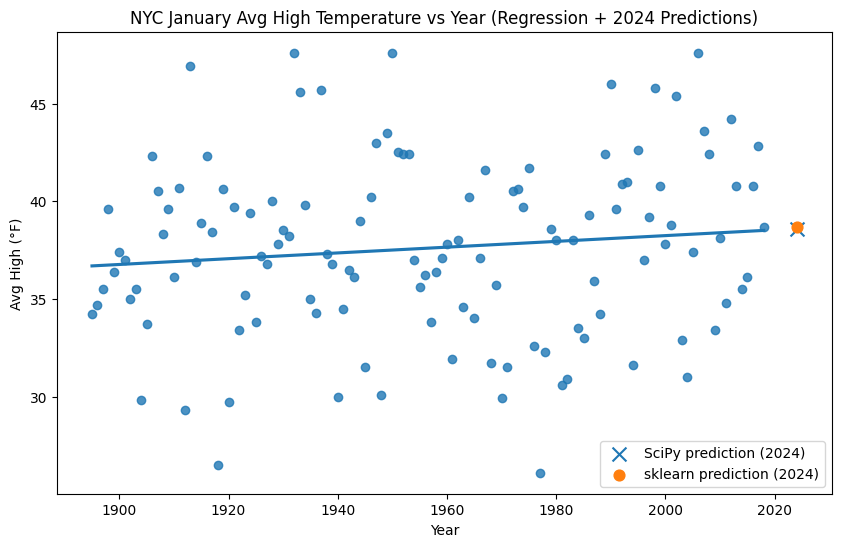

In [196]:
# Section 5 - Project Highlight Chart

ax = sns.regplot(x="year", y="avg_high", data=nyc_clean, ci=None)

# Mark the 2024 predictions from both approaches
plt.scatter(
    [2024], [pred_2024_scipy], marker="x", s=100, label="SciPy prediction (2024)"
)
plt.scatter(
    [2024], [pred_2024_sklearn], marker="o", s=60, label="sklearn prediction (2024)"
)

plt.title("NYC January Avg High Temperature vs Year (Regression + 2024 Predictions)")
plt.xlabel("Year")
plt.ylabel("Avg High (°F)")
plt.legend()

# Save image for README
Path("docs/images").mkdir(parents=True, exist_ok=True)
plt.savefig("docs/images/project_highlight.png", dpi=200, bbox_inches="tight")

plt.show()

## Part 4 - Insights

### Comparison of SciPy vs scikit-learn
- **SciPy (`linregress`)** is quick and transparent: it directly returns slope/intercept and useful statistics (like the correlation value). It’s great for understanding the regression relationship and getting a fast prediction.
- **scikit-learn (`LinearRegression`)** fits into a larger machine learning workflow: train/test split, model evaluation, pipelines, and extension to multiple features. It’s a better tool when you want to scale beyond a single-variable regression.

### Why predictions may differ
Even though both methods are linear regression, predictions can differ slightly because:
- In **Part 2**, the model uses the full dataset to compute the regression line.
- In **Part 3**, we used a **train/test split**, so the fitted line is based only on the training subset (and `random_state` / `test_size` affect which points are used for training).

### 2024 Prediction Summary
The notebook prints both 2024 predictions in the code cell directly below.

In [197]:
print(f"SciPy 2024 prediction: {pred_2024_scipy:.2f}°F")
print(f"scikit-learn 2024 prediction: {pred_2024_sklearn:.2f}°F")

SciPy 2024 prediction: 38.59°F
scikit-learn 2024 prediction: 38.67°F
